In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sympy.physics.units import degrees

In [2]:
original_df = pd.read_csv("xy_data.csv")
original_df.head()

,x,y
0,88.364456,57.784378
1,74.283936,54.406780
2,60.256474,46.311462
3,82.134370,57.717567
4,101.036390,67.849340


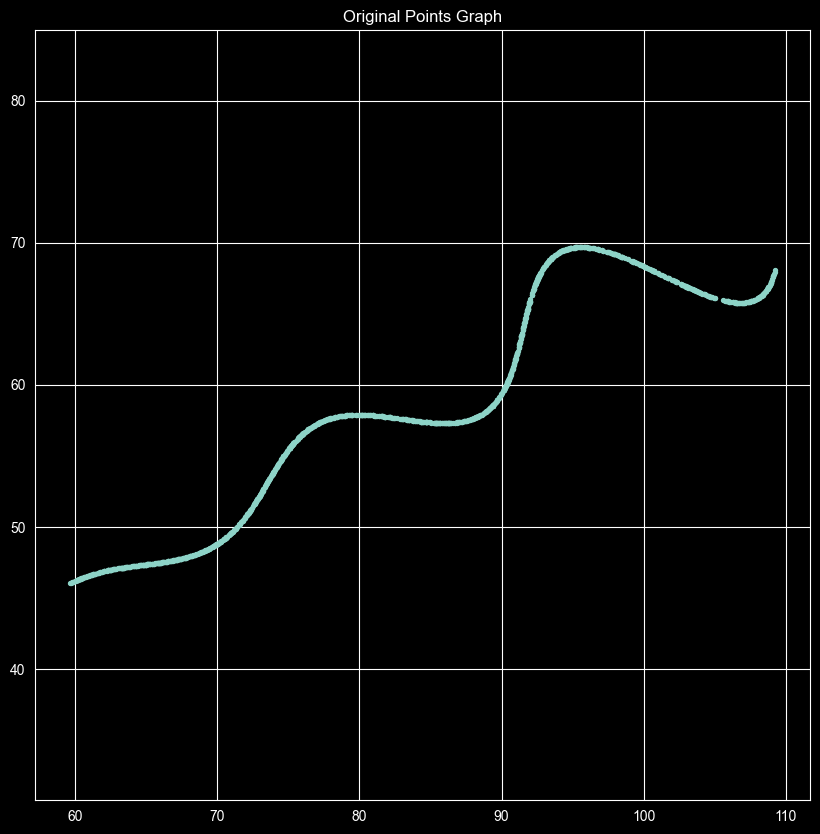

In [3]:
plt.figure(figsize=(10,10))

plt.scatter(
    original_df["x"],
    original_df["y"],
    s=8
)

plt.axis("equal")
plt.grid(True)

plt.title("Original Points Graph")
plt.show()

In [6]:
points = original_df[["x", "y"]].to_numpy()

pca = PCA(n_components=2)
pca.fit(points)

pc1 = pca.components_[0]

theta0 = np.arctan2(pc1[1], pc1[0])

print(f"Theta (rad): {theta0:.6f}")
print(f"Theta (degree): {np.degrees(theta0):.6f}")

Theta (rad): 0.497125
Theta (degree): 28.483144


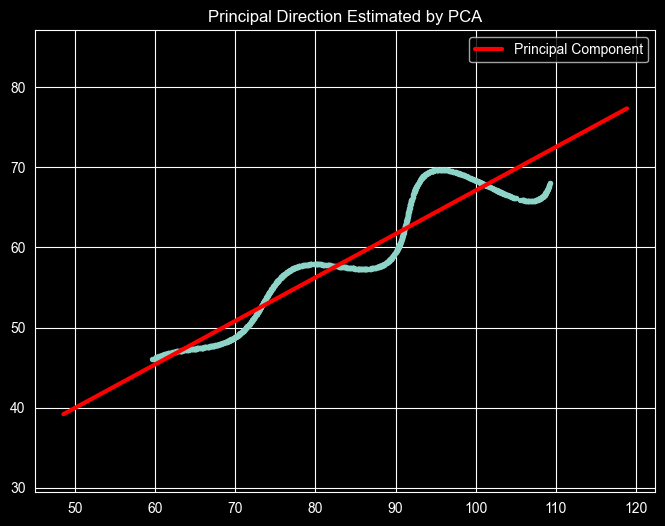

In [7]:
center = points.mean(axis=0)
length = 40
direction = pc1 * length
plt.figure(figsize=(8,6))

plt.scatter(
    original_df["x"],
    original_df["y"],
    s=8
)

plt.plot(
    [center[0]-direction[0], center[0]+direction[0]],
    [center[1]-direction[1], center[1]+direction[1]],
    color="red",
    linewidth=3,
    label="Principal Component"
)

plt.axis("equal")
plt.grid(True)
plt.legend()
plt.title("Principal Direction Estimated by PCA")

plt.show()

In [8]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

Explained variance ratio:
[0.9770017 0.0229983]


In [9]:
c = np.cos(theta0)
s = np.sin(theta0)

u = original_df["x"] * c + original_df["y"] * s

v = -original_df["x"] * s + original_df["y"] * c

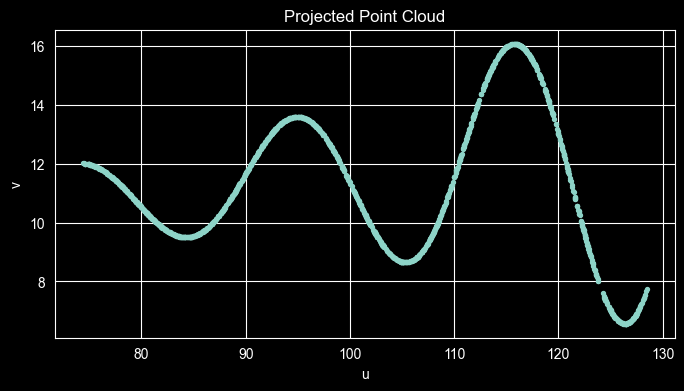

In [10]:
plt.figure(figsize=(8,4))
plt.scatter(u, v, s=8)

plt.xlabel("u")
plt.ylabel("v")
plt.grid(True)

plt.title("Projected Point Cloud")

plt.show()

In [11]:
u_min = u.min()
u_max = u.max()

C = ((u_min - 6) + (u_max - 60)) / 2

print("Estimated C =", C)

Estimated C = 68.4279830944779


In [12]:
print(u_min)
print(u_max)

74.38895461084948
128.4670115781063


In [14]:
t = u - C

Text(0.5, 1.0, 'Recovered t')

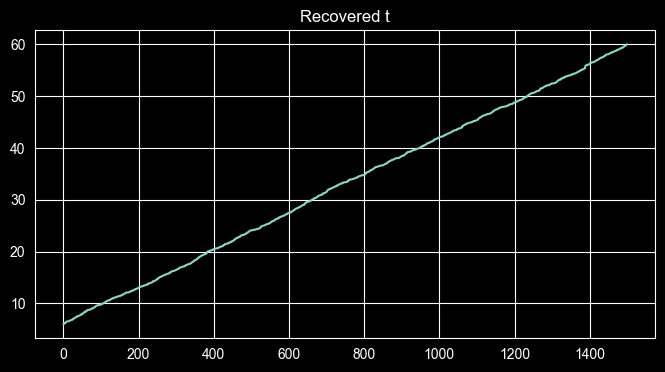

In [15]:
plt.figure(figsize=(8,4))
plt.plot(np.sort(t))
plt.grid(True)
plt.title("Recovered t")

In [16]:
D = np.mean(v)
print(D)

11.28796362101226


In [17]:
X = (42*np.cos(theta0)-D)/np.sin(theta0)
print(X)

53.739229412590426


In [18]:
print(C)
print(D)
print(X)
print(t.min(), t.max())

68.4279830944779
11.28796362101226
53.739229412590426
5.960971516371586 60.039028483628414


In [19]:
v_centered = v - D

In [23]:
Ms = np.linspace(-0.05,0.05,4001)

In [24]:
best_M = None
best_loss = np.inf

for M in Ms:

    pred = np.exp(M*t) * np.sin(0.3*t)

    loss = np.mean(np.abs(v_centered - pred))

    if loss < best_loss:
        best_loss = loss
        best_M = M

In [25]:
print(best_M)
print(best_loss)

0.026874999999999996
0.3820256595313944


In [33]:
def model(theta, X, M, t):

    oscillation = np.exp(M * t) * np.sin(0.3 * t)
    x = (
        t * np.cos(theta)
        - oscillation * np.sin(theta)
        + X
    )
    y = (
        42
        + t * np.sin(theta)
        + oscillation * np.cos(theta)
    )

    return x, y

In [34]:
x_pred, y_pred = model(
    theta0,
    X,
    best_M,
    t
)

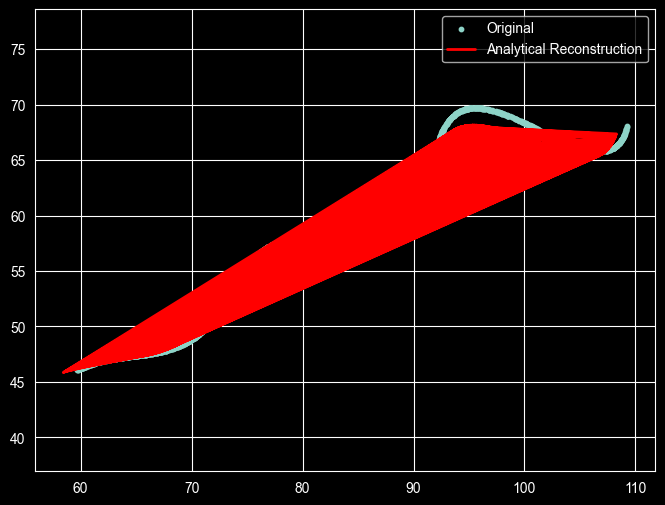

In [35]:
plt.figure(figsize=(8,6))

plt.scatter(
    original_df["x"],
    original_df["y"],
    s=10,
    label="Original"
)

plt.plot(
    x_pred,
    y_pred,
    color="red",
    linewidth=2,
    label="Analytical Reconstruction"
)

plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()

In [36]:
print(np.all(np.diff(t) >= 0))

False


In [37]:
idx = np.argsort(t)

t_sorted = t[idx]

x_pred, y_pred = model(
    theta0,
    X,
    best_M,
    t_sorted
)

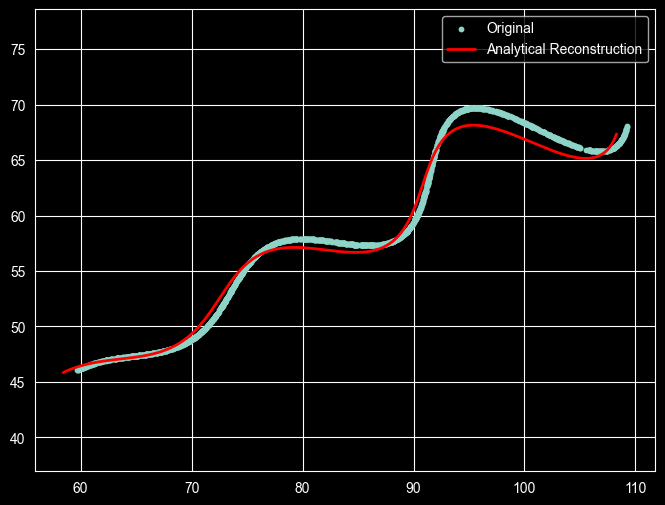

In [38]:
plt.figure(figsize=(8,6))

plt.scatter(
    original_df["x"],
    original_df["y"],
    s=10,
    label="Original"
)

plt.plot(
    x_pred,
    y_pred,
    color="red",
    linewidth=2,
    label="Analytical Reconstruction"
)

plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()

In [39]:
L1 = np.mean(
    np.abs(x_pred - original_df["x"].to_numpy()) +
    np.abs(y_pred - original_df["y"].to_numpy())
)

print(f"L1 Error = {L1:.6f}")

L1 Error = 25.230127


In [40]:
L1_total = np.sum(
    np.abs(x_pred - original_df["x"].to_numpy()) +
    np.abs(y_pred - original_df["y"].to_numpy())
)

print(f"Total L1 Error = {L1_total:.6f}")

Total L1 Error = 37845.190720
